# Tổng quan EDA

## Mục tiêu đồ án

Notebook này thực hiện phân tích khám phá dữ liệu (EDA) cho bài toán **dự đoán doanh thu phim**.

Trong bài toán này, biến mục tiêu cần dự đoán là:

- `revenue`: doanh thu phim

Mục tiêu của EDA là tìm hiểu xem các thông tin có thể biết trước khi phim phát hành như `budget`, `genres`, `director`, `release_date`, `runtime` có thể hỗ trợ như thế nào cho việc dự đoán doanh thu.

## Vai trò của EDA

File EDA này không trực tiếp xử lý feature cuối cùng và không huấn luyện mô hình. Thay vào đó, EDA dùng để:

- hiểu phân phối của `revenue`;
- phát hiện dữ liệu bị lệch, thiếu hoặc có outlier;
- kiểm tra mối quan hệ giữa các biến đầu vào và doanh thu;
- giải thích vì sao các bước xử lý ở file Feature Engineering là hợp lý.

## Nguyên tắc tránh rò rỉ dữ liệu

Trong bài toán dự đoán doanh thu, mô hình chỉ nên dùng các thông tin có thể biết trước khi phim phát hành.

Các biến có thể dùng làm input:

- `budget`
- `genres`
- `director`
- `release_date`
- `runtime`
- các biến được tách từ `release_date` như `release_year`, `release_month`, `release_quarter`, `is_weekend`

Các biến không được dùng làm input vì gây leakage:

- `revenue`
- `log_revenue`
- `profit`
- `ROI`
- `roi_class`
- `success_class`
- `vote_average`
- `vote_count`
- `popularity`

Trong notebook này, `revenue` chỉ được dùng làm biến mục tiêu để phân tích. Nếu tạo `log_revenue`, biến này cũng chỉ được xem là target biến đổi, không phải input feature.

# Load data

In [ ]:
import pandas as pd

df = pd.read_csv('../data/processed/movie_final.csv')
df.head()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6591 entries, 0 to 6590
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 6591 non-null   int64  
 1   title              6591 non-null   object 
 2   budget             4361 non-null   float64
 3   revenue            4374 non-null   float64
 4   release_date       6563 non-null   object 
 5   genres             6454 non-null   object 
 6   vote_average       6591 non-null   float64
 7   vote_count         6591 non-null   int64  
 8   runtime            6578 non-null   float64
 9   original_language  6591 non-null   object 
 10  director           6497 non-null   object 
dtypes: float64(4), int64(2), object(5)
memory usage: 566.5+ KB


In [ ]:
df.shape

(6591, 11)

In [ ]:
df.isnull().sum()

,0
id,0
title,0
budget,2230
revenue,2217
release_date,28
genres,137
vote_average,0
vote_count,0
runtime,13
original_language,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Chia nhóm feature

In [ ]:
num_cols = ['id', 'budget', 'revenue', 'runtime', 'vote_average', 'vote_count']
cat_cols = ['title', 'release_date', 'genres', 'original_language', 'director']

# Thống kê mô tả

In [ ]:
df[[col for col in num_cols if col != 'id']].describe().round(2)

,budget,revenue,runtime,vote_average,vote_count
count,4.361000e+03,4.374000e+03,6578.00,6591.00,6591.00
mean,3.808171e+07,2.450429e+07,87.98,5.27,17097.44
std,6.971745e+08,1.212889e+08,38.71,2.48,56659.53
min,0.000000e+00,1.000000e+00,0.00,0.00,0.00
25%,5.000000e+03,3.812750e+03,84.00,4.50,409.50
50%,2.000000e+05,1.381360e+05,95.50,5.80,2100.00
75%,4.800000e+06,2.163914e+06,107.00,6.80,7800.00
max,2.800000e+10,2.334485e+09,564.00,10.00,1000000.00


# EDA

### Numeric


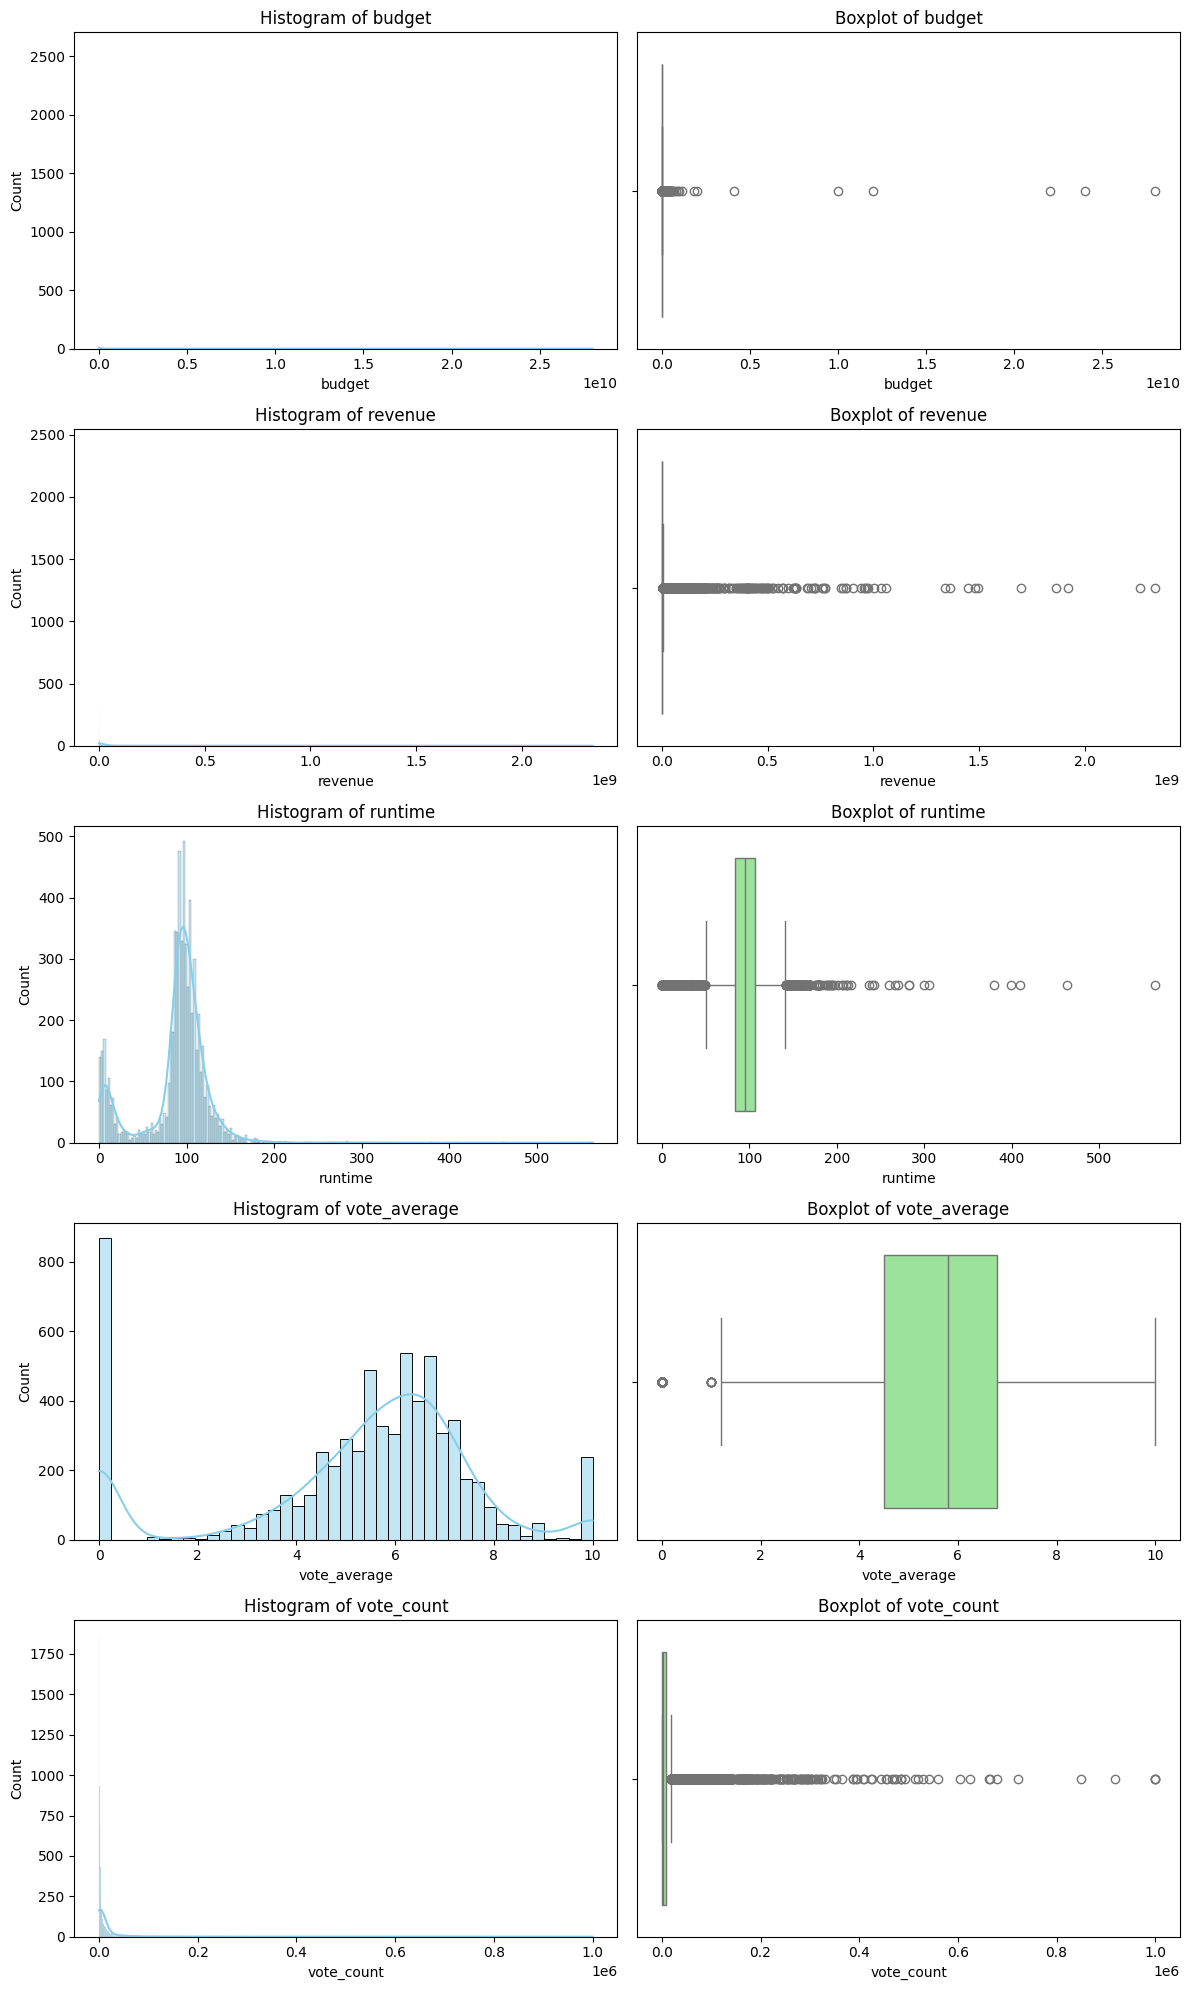

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

num_cols = ['budget', 'revenue', 'runtime', 'vote_average', 'vote_count']

# Convert numeric
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Plot
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))

for i, col in enumerate(num_cols):

    data = df[col]

    # Histogram (seaborn tự ignore NaN)
    sns.histplot(data, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram of {col}')

    # Boxplot (lọc NaN nhẹ để tránh lỗi)
    sns.boxplot(x=data.dropna(), ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Nhận xét**: Ta nhận thấy hầu hết các biến numerical đều bị lệch phải mạnh, có nhiều outliers và không có phân phối chuẩn. Đặc biệt, các biến `budget`, `revenue` và `vote_count` xuất hiện nhiều outlier với khoảng giá trị rất lớn. Vì vậy, cần áp dụng các kỹ thuật xử lý outlier và biến đổi dữ liệu như log transformation, winsorize trước khi xây dựng mô hình học máy. Và chỉ áp dụng nó với các cột: `revenue`, `budget`, `runtime`, `vote_count`; không áp dụng cho cột `vote_average`.

In [ ]:
import numpy as np


def log_transform(df, num_cols, exclude_cols=['vote_average', 'runtime']):

    log_cols = [col for col in num_cols if col not in exclude_cols]

    for col in log_cols:
        df[col] = np.log1p(df[col])

    return df

In [ ]:
df = log_transform(df, num_cols)

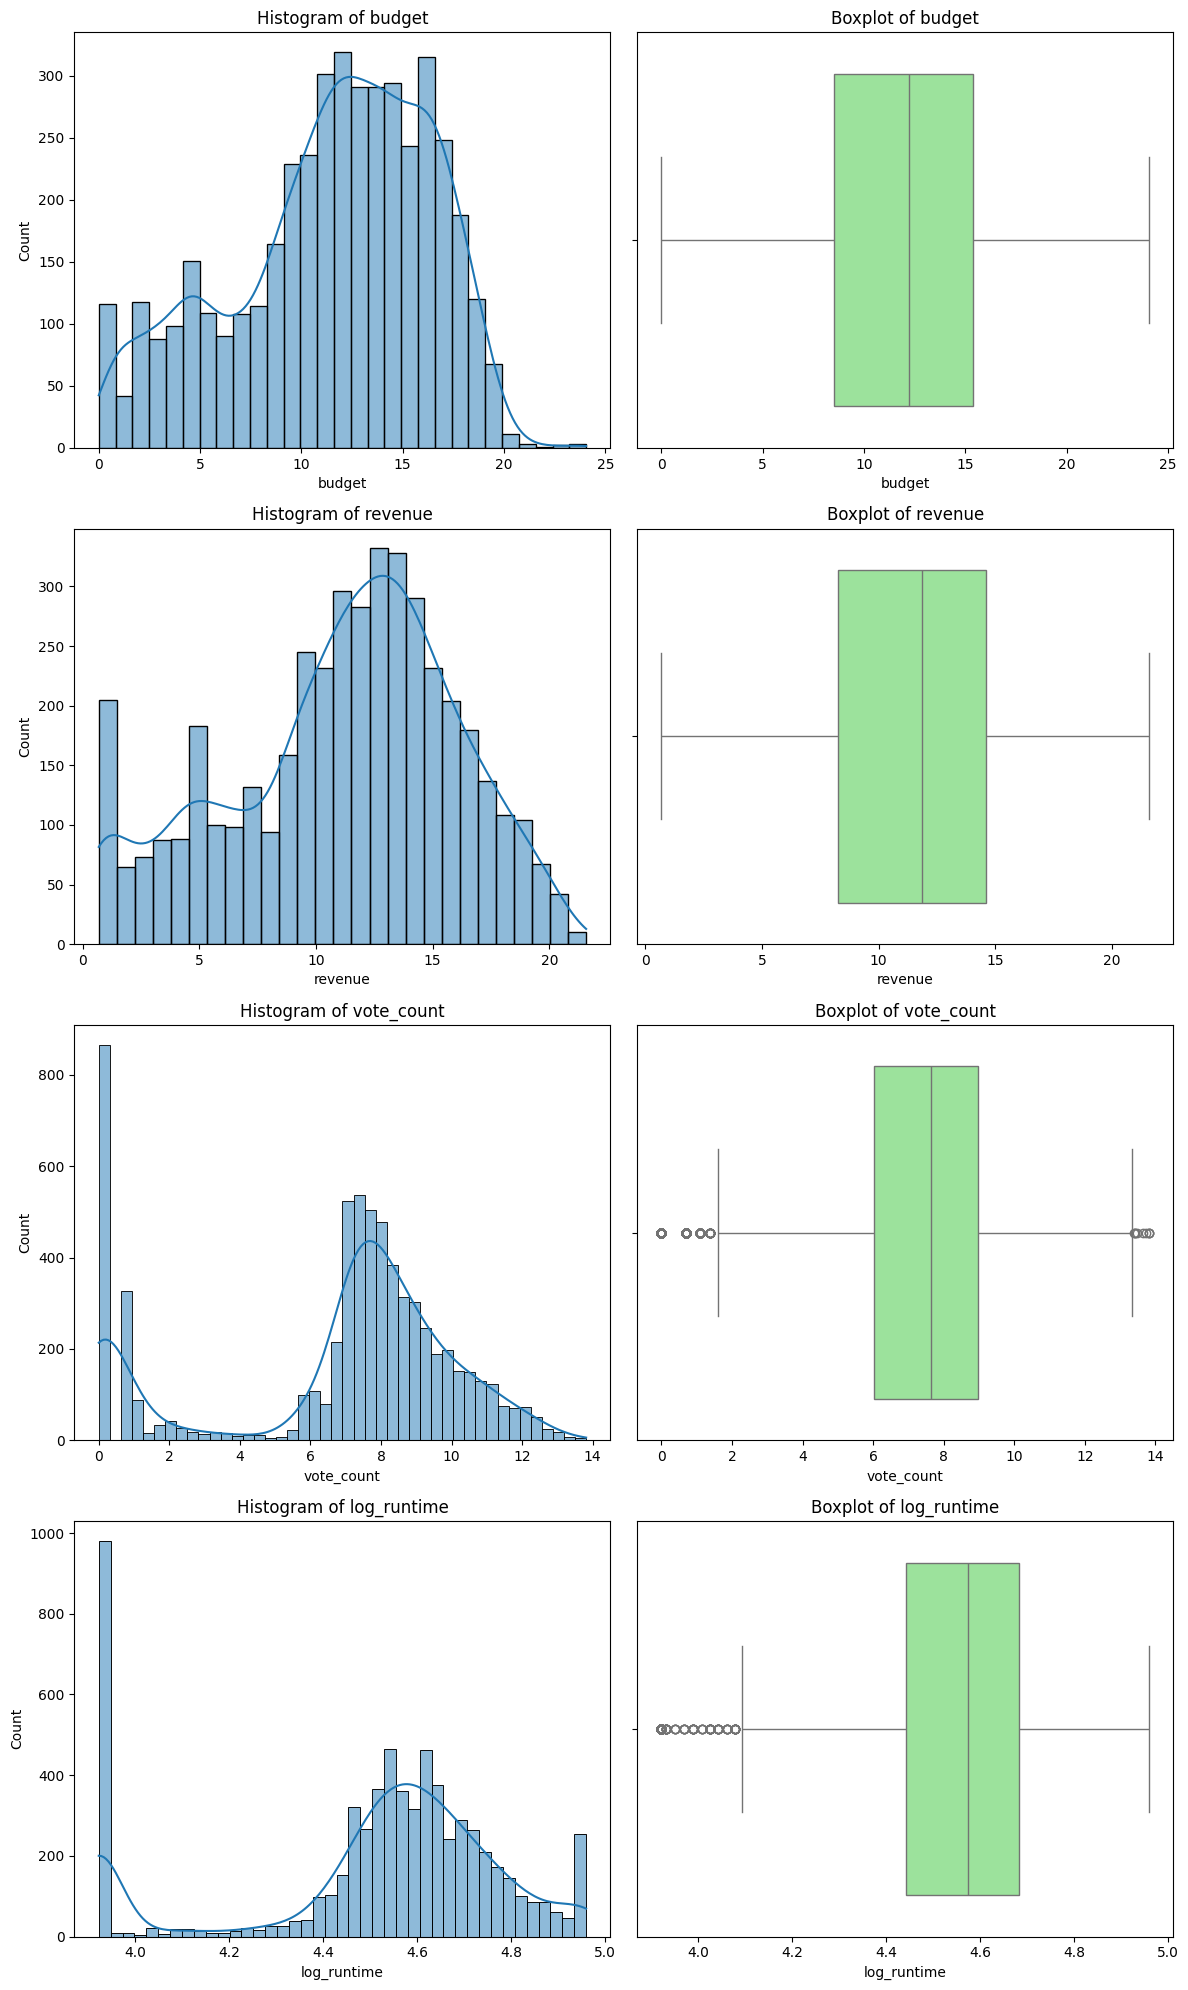

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Các cột muốn vẽ sau khi log transform
log_cols = [
    col for col in num_cols
    if col not in ['vote_average', 'runtime']
]
df['log_runtime'] = np.log1p(df['runtime'])
log_cols.append('log_runtime')

# Vẽ histogram và boxplot
fig, axes = plt.subplots(len(log_cols), 2, figsize=(12, 5 * len(log_cols)))

# Nếu chỉ có 1 cột
if len(log_cols) == 1:
    axes = [axes]

for i, col in enumerate(log_cols):

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i][0])
    axes[i][0].set_title(f'Histogram of {col}')

    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i][1], color='lightgreen')
    axes[i][1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

**Nhận xét:** Sau khi áp dụng log transformation cho các cột thì ta thấy kỹ thuật này hoạt động tốt ở các cột `budget`, `revenue` và `vote_count`.

In [ ]:
# Winsorize cột runtime
# Bước 1: Thay 0 bằng NaN (dữ liệu lỗi)
df['runtime'] = df['runtime'].replace(0, np.nan)

# Bước 2: Tính ngưỡng IQR
Q1  = df['runtime'].quantile(0.25)
Q3  = df['runtime'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Winsorize runtime: clip về [{lower:.1f}, {upper:.1f}] phút")

# Bước 3: Clip giá trị ngoài ngưỡng
df['runtime'] = df['runtime'].clip(lower=lower, upper=upper)

print(df['runtime'].describe().round(2))

Winsorize runtime: clip về [49.5, 141.5] phút
count    6534.00
mean       93.09
std        24.04
min        49.50
25%        84.00
50%        96.00
75%       107.00
max       141.50
Name: runtime, dtype: float64


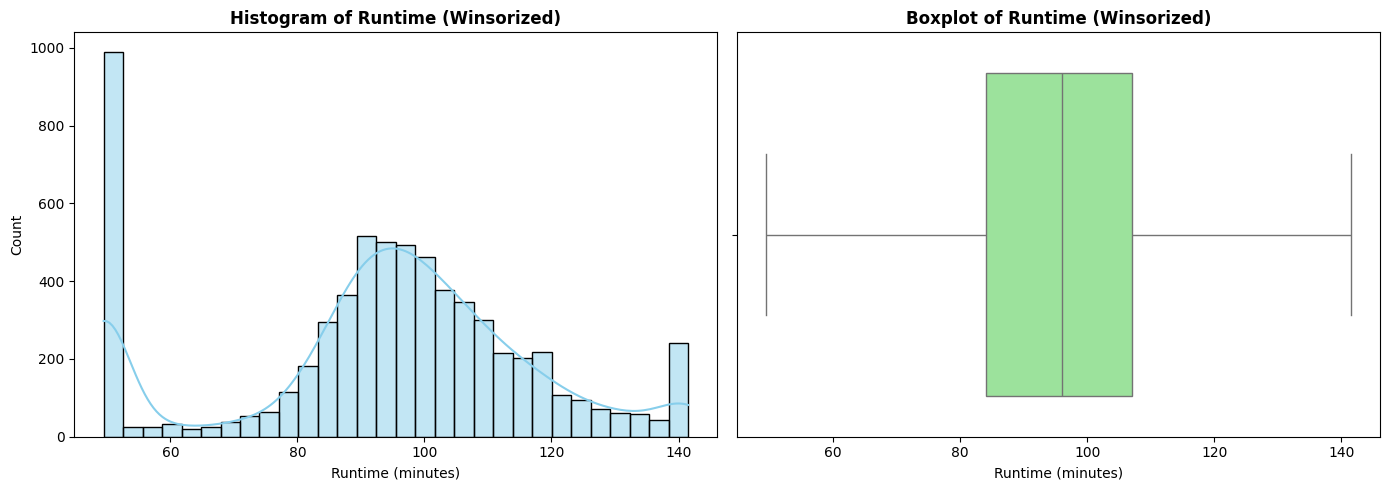

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ Histogram + Boxplot cho runtime
# sau khi Winsorize


fig, axes = plt.subplots(
    1, 2,
    figsize=(14,5)
)

# Histogram

sns.histplot(
    df['runtime'],
    bins=30,
    kde=True,
    ax=axes[0],
    color='skyblue'
)

axes[0].set_title(
    'Histogram of Runtime (Winsorized)',
    fontweight='bold'
)

axes[0].set_xlabel('Runtime (minutes)')
axes[0].set_ylabel('Count')

# Boxplot
sns.boxplot(
    x=df['runtime'],
    ax=axes[1],
    color='lightgreen'
)

axes[1].set_title(
    'Boxplot of Runtime (Winsorized)',
    fontweight='bold'
)

axes[1].set_xlabel('Runtime (minutes)')

plt.tight_layout()
plt.show()

**Nhận xét:** Ta thấy `runtime` sẽ phù hợp với phương pháp Winsorized hơn là Log Transformation

Do cột `vote_count` và `vote_avarage` được ghi nhận sau khi phim đã phát hành, vì vậy nó không phù hợp với bài toán nên nhóm quyết định drop 2 cột này.

In [ ]:
df = df.drop(columns = ['vote_count', 'vote_average'])
num_cols.remove('vote_count')
num_cols.remove('vote_average')

### Categorical

In [ ]:
# Display number of unique values per categorical column
for col in cat_cols:
    print(f"Variable: {col} has {df[col].nunique()} unique values")

Variable: title has 6591 unique values
Variable: release_date has 1752 unique values
Variable: genres has 748 unique values
Variable: original_language has 1 unique values
Variable: director has 5221 unique values


Drop các cột id, title và original_language. Vì:
- Chúng có tính duy nhất cao và hoạt động như các ID, cung cấp ít thông tin có thể khái quát hóa.

- Mô hình không thể học được các mẫu có ý nghĩa từ các định danh như vậy.

- Có nguy cơ quá khớp, vì mô hình có thể ghi nhớ các giá trị ID cụ thể thay vì khái quát hóa các mẫu.

In [ ]:
# Drop cột không cần thiết
drop_cols = ['id', 'title', "original_language"]
df = df.drop(columns=drop_cols)

# Cập nhật list cat_cols
cat_cols = [col for col in cat_cols if col not in drop_cols]

Vì cột director và genres có nhiều giá trị trong cùng ô nên để đơn giản việc xử lý thì ta sẽ chỉ lấy giá trị director đầu tiên trong mảng làm đạo diễn chính.

Đồng thời convert cột release_date sang datetime. Cột genres sẽ được split ra.

In [ ]:
import re
import pandas as pd

# Lấy đạo diễn chính
def get_main_director(x):

    if pd.isnull(x):
        return x

    # Split theo nhiều separator
    directors = re.split(r'\||,|;', x)

    return directors[0].strip()
df['director'] = df['director'].apply(get_main_director)



# Convert release_date sang datetime
df['release_date'] = pd.to_datetime(
    df['release_date'],
    errors='coerce'
)

# Tách lấy năm/tháng/ngày
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_day'] = df['release_date'].dt.day

# Split genres
df['genres_split'] = df['genres'].fillna('').apply(lambda x: x.split('|'))


from collections import Counter

genre_counter = Counter()

for genres in df['genres_split']:
    genre_counter.update(genres)

# Dataframe
genre_df = pd.DataFrame(
    genre_counter.items(),
    columns=['genre', 'count']
).sort_values(by='count', ascending=False)


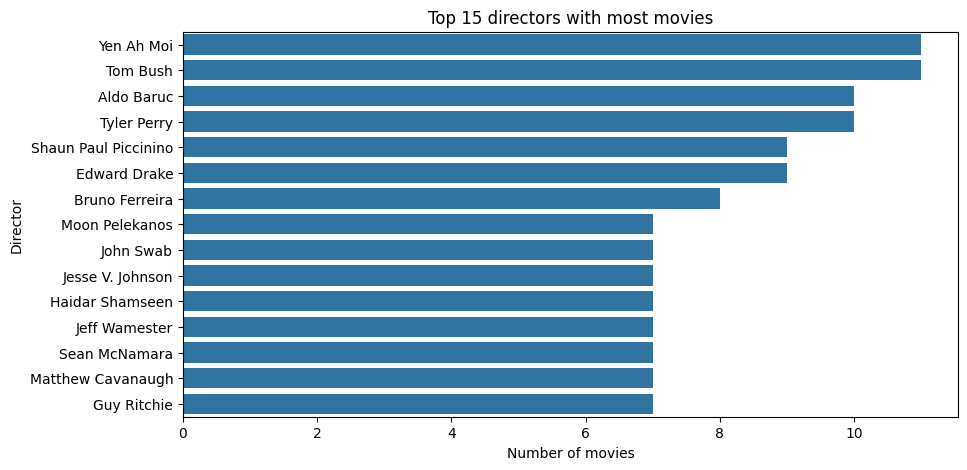

In [ ]:
# Top 15 đạo diẽn có nhiều phim nhất
top_directors = df['director'].value_counts().head(15)

plt.figure(figsize=(10,5))
sns.barplot(
    x=top_directors.values,
    y=top_directors.index
)

plt.title('Top 15 directors with most movies')
plt.xlabel('Number of movies')
plt.ylabel('Director')
plt.show()

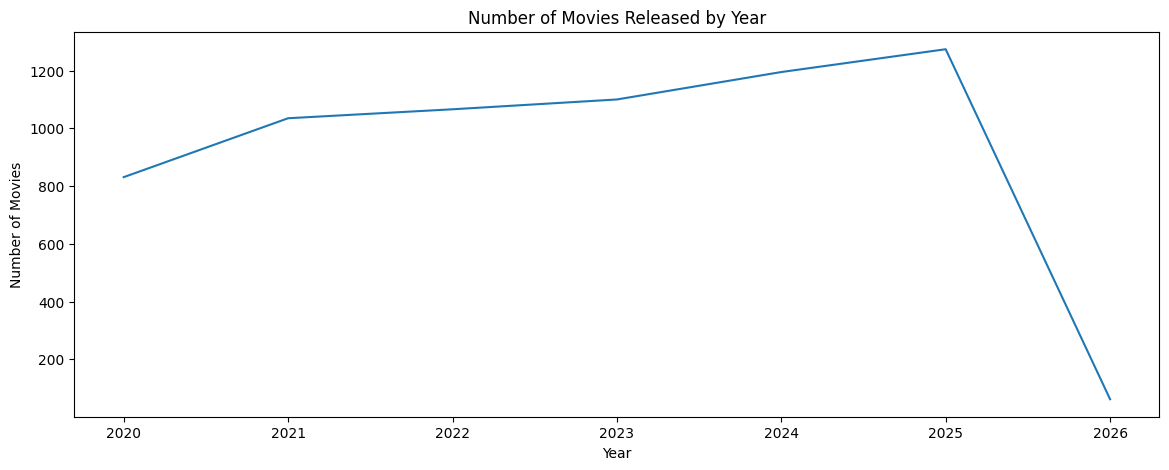

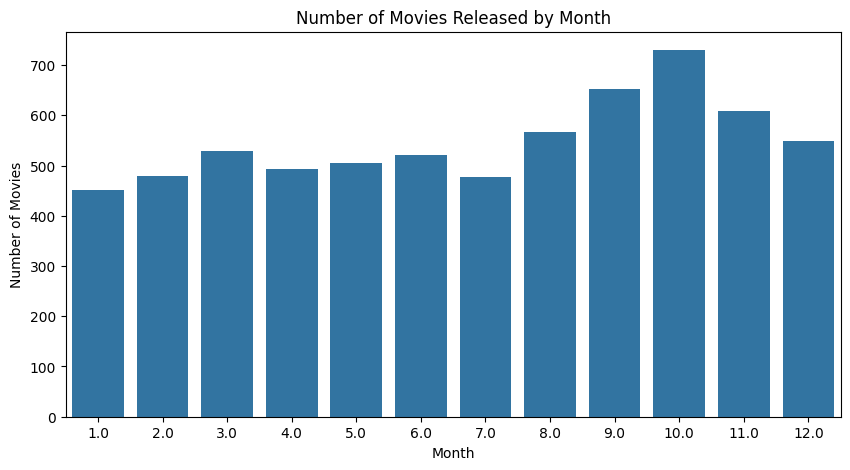

In [ ]:
# Số lượng phim theo năm

movies_by_year = (
    df['release_year']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,5))

sns.lineplot(
    x=movies_by_year.index,
    y=movies_by_year.values
)

plt.title('Number of Movies Released by Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')

plt.show()


# Số lượng phim theo tháng

movies_by_month = (
    df['release_month']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=movies_by_month.index,
    y=movies_by_month.values
)

plt.title('Number of Movies Released by Month')
plt.xlabel('Month')
plt.ylabel('Number of Movies')

plt.show()

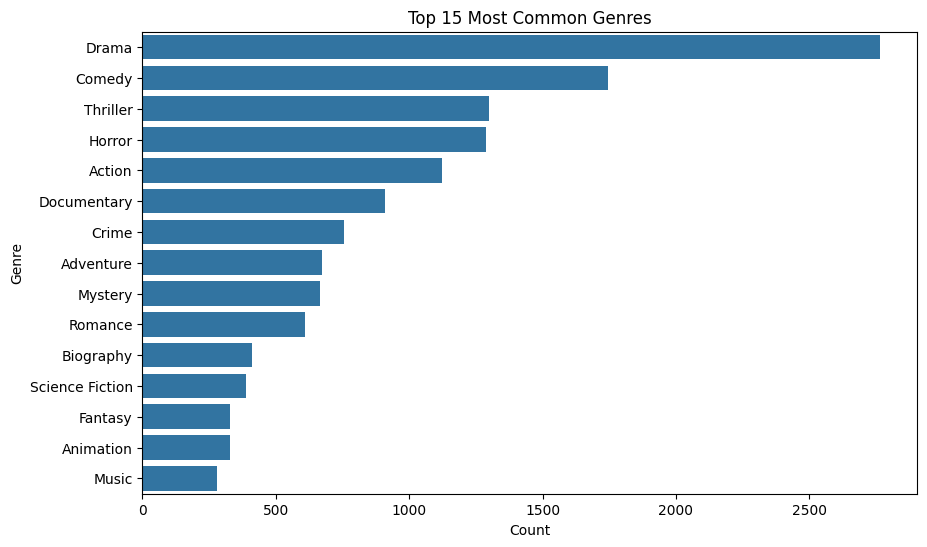

In [ ]:
# Top 15 thể loại phim
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_df.head(15),
    x='count',
    y='genre'
)

plt.title('Top 15 Most Common Genres')
plt.xlabel('Count')
plt.ylabel('Genre')

plt.show()

**Nhận xét:**

# Statistical Testing

### Numeric

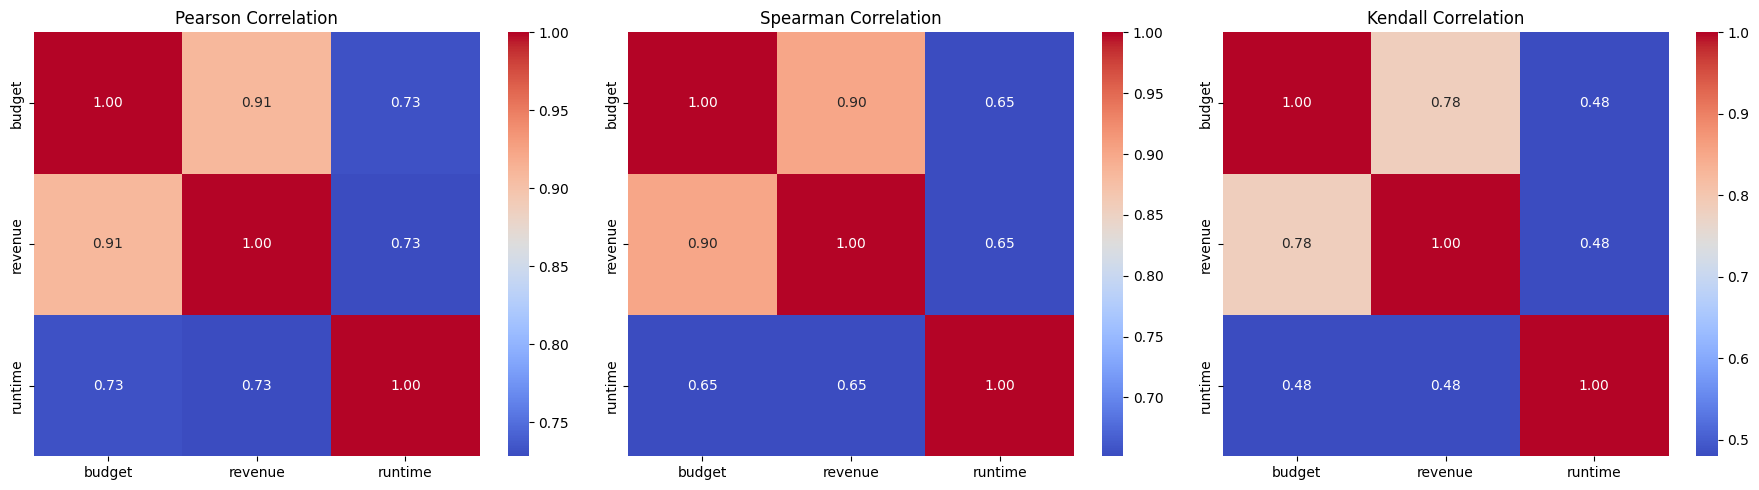

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Các biến số
num_cols = ['budget', 'revenue', 'runtime']

# Convert về numeric
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Bỏ NaN
df_1 = df[num_cols].dropna()

# Tính correlation
corr_pearson = df_1.corr(method='pearson')
corr_spearman = df_1.corr(method='spearman')
corr_kendall = df_1.corr(method='kendall')

# Vẽ 3 heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(corr_pearson, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title('Pearson Correlation')

sns.heatmap(corr_spearman, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Spearman Correlation')

sns.heatmap(corr_kendall, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Kendall Correlation')

plt.tight_layout()
plt.show()

**Nhận xét:**

### Categorical

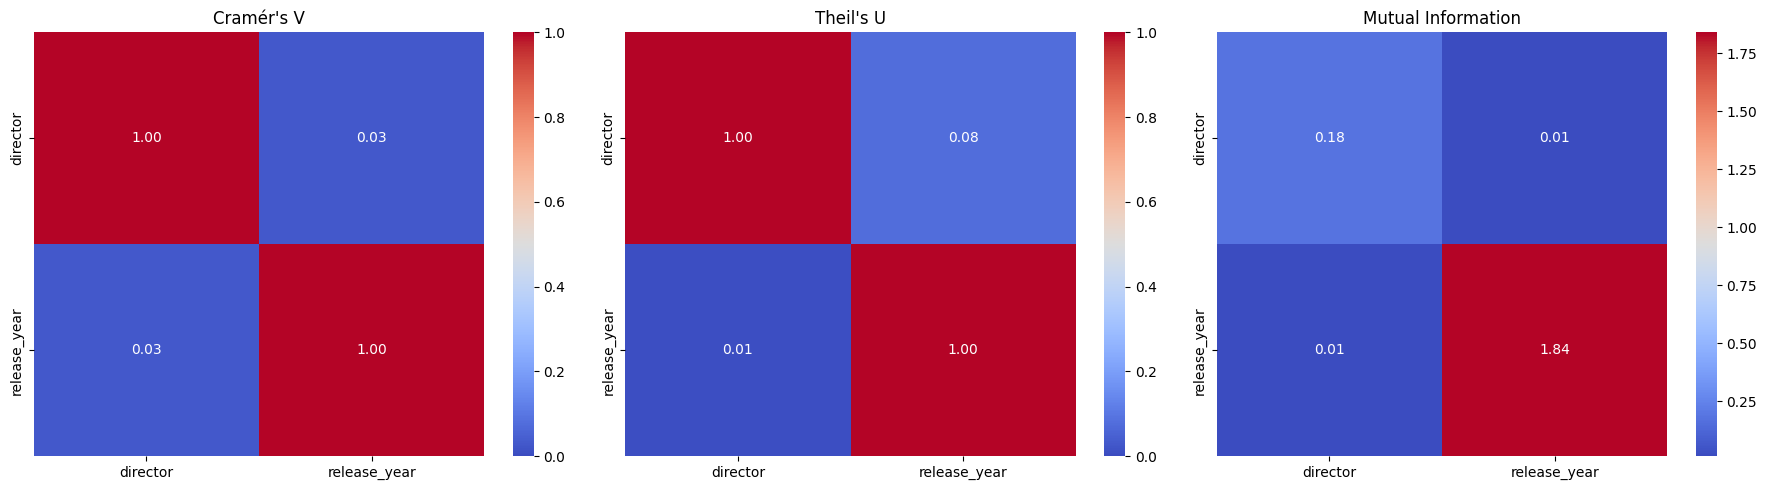

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score

cat_cols = ['release_date', 'director']

df_cat = df[cat_cols].copy()

# Xử lý release_date -> release_year
df_cat['release_year'] = pd.to_datetime(df_cat['release_date'], errors='coerce').dt.year.astype('Int64').astype(str)
df_cat = df_cat.drop(columns=['release_date'])

# Xử lý director -> chỉ giữ top 20, còn lại gom thành Other
top_directors = df_cat['director'].value_counts().head(20).index
df_cat['director'] = df_cat['director'].where(
    df_cat['director'].isin(top_directors),
    'Other'
)

# Làm sạch dữ liệu categorical
for col in df_cat.columns:
    df_cat[col] = df_cat[col].astype(str).fillna('Unknown')

cat_cols_clean = df_cat.columns.tolist()

# -----------------------------
# 1. Cramer's V
# -----------------------------
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    r, k = confusion_matrix.shape

    # Bias correction
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


# -----------------------------
# 2. Theil's U
# -----------------------------
def conditional_entropy(x, y):
    y_counter = y.value_counts()
    xy_counter = pd.crosstab(x, y)

    total_occurrences = len(x)
    entropy = 0

    for y_val in y_counter.index:
        p_y = y_counter[y_val] / total_occurrences
        x_given_y = xy_counter[y_val]
        p_x_given_y = x_given_y / x_given_y.sum()
        p_x_given_y = p_x_given_y[p_x_given_y > 0]

        entropy += p_y * (-np.sum(p_x_given_y * np.log2(p_x_given_y)))

    return entropy


def theils_u(x, y):
    """
    Theil's U: mức độ y dự đoán được x
    U(x|y)
    """
    s_xy = conditional_entropy(x, y)
    x_counter = x.value_counts()
    total = len(x)
    p_x = x_counter / total
    s_x = -np.sum(p_x * np.log2(p_x[p_x > 0]))

    if s_x == 0:
        return 1
    return (s_x - s_xy) / s_x


# -----------------------------
# 3. Mutual Information
# -----------------------------
def mutual_info(x, y):
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    x_enc = le.fit_transform(x.astype(str))
    y_enc = le.fit_transform(y.astype(str))
    return mutual_info_score(x_enc, y_enc)


# Tính ma trận
n = len(cat_cols_clean)
cramers_matrix = pd.DataFrame(index=cat_cols_clean, columns=cat_cols_clean, dtype=float)
theils_matrix  = pd.DataFrame(index=cat_cols_clean, columns=cat_cols_clean, dtype=float)
mi_matrix      = pd.DataFrame(index=cat_cols_clean, columns=cat_cols_clean, dtype=float)

for col1 in cat_cols_clean:
    for col2 in cat_cols_clean:
        cramers_matrix.loc[col1, col2] = cramers_v(df_cat[col1], df_cat[col2])
        theils_matrix.loc[col1, col2]  = theils_u(df_cat[col1], df_cat[col2])
        mi_matrix.loc[col1, col2]      = mutual_info(df_cat[col1], df_cat[col2])

# Vẽ 3 heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(cramers_matrix.astype(float), annot=True, cmap='coolwarm',
            fmt='.2f', ax=axes[0], vmin=0, vmax=1)
axes[0].set_title("Cramér's V")

sns.heatmap(theils_matrix.astype(float), annot=True, cmap='coolwarm',
            fmt='.2f', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Theil's U")

sns.heatmap(mi_matrix.astype(float), annot=True, cmap='coolwarm',
            fmt='.2f', ax=axes[2])
axes[2].set_title('Mutual Information')

plt.tight_layout()
plt.show()


**Nhận xét:**

# Feature Engineering

## Tạo thêm features từ release_date

In [ ]:
# release_year và release_month đã tạo ở trên
# Thứ 6 (4), Thứ 7 (5), Chủ nhật (6) = cuối tuần -> phim thường ra mắt thứ 6
df['is_weekend'] = df['release_date'].dt.dayofweek.isin([4, 5, 6]).astype(int)

# Quarter: quý
df['release_quarter']     = df['release_date'].dt.quarter

# Mùa hè: tháng 6-8 — mùa cao điểm blockbuster
df['is_summer']           = df['release_month'].isin([6, 7, 8]).astype(int)

# Mùa lễ: tháng 11-12 — Oscar season, Giáng sinh
df['is_holiday_season']   = df['release_month'].isin([11, 12]).astype(int)

# Số ngày kể từ 2020-01-01 — capture xu hướng tuyến tính theo thời gian
df['days_since_2020']     = (
    df['release_date'] - pd.Timestamp('2020-01-01')
).dt.days

date_cols = ['release_quarter', 'is_weekend', 'is_summer',
                 'is_holiday_season', 'days_since_2020', 'release_year', 'release_month']
print("Phân phối is_weekend:")
print(df['is_weekend'].value_counts())

Phân phối is_weekend:
is_weekend
1    3756
0    2835
Name: count, dtype: int64


## Vẽ biểu đồ phân phối

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

SAGE  = '#9DC183'
DARK  = '#5DA68B'
MUTED = '#95a5a6'
RED   = '#e74c3c'

month_names = ['Jan','Feb','Mar','Apr','May',
               'Jun','Jul','Aug','Sep','Oct','Nov','Dec']


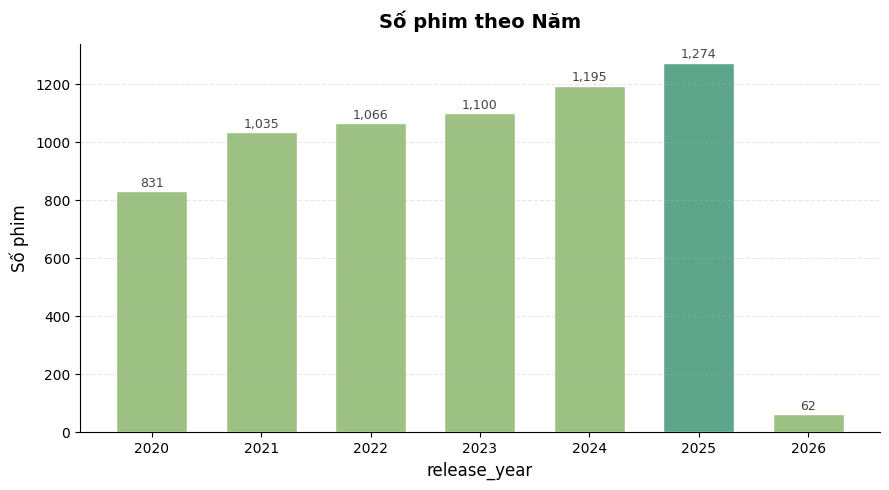

In [ ]:
# ── release_year ─────────────────────────────────────────────────────────────
counts = df['release_year'].value_counts().sort_index()
x_vals = counts.index.astype(int)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [DARK if v == counts.max() else SAGE for v in counts.values]
bars = ax.bar(x_vals, counts.values, color=bar_colors, edgecolor='white', width=0.65)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h):,}',
            ha='center', va='bottom', fontsize=9, color='#444')

ax.set_title('Số phim theo Năm', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('release_year', fontsize=12)
ax.set_ylabel('Số phim', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


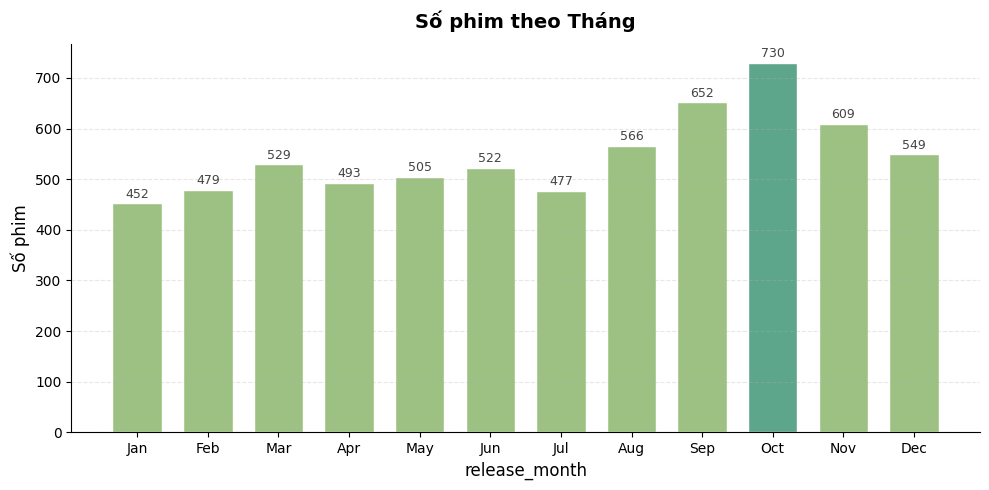

In [ ]:
# ── release_month ─────────────────────────────────────────────────────────────
counts = df['release_month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [DARK if v == counts.max() else SAGE for v in counts.values]
bars = ax.bar(counts.index.astype(int), counts.values,
              color=bar_colors, edgecolor='white', width=0.7)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h):,}',
            ha='center', va='bottom', fontsize=9, color='#444')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=10)
ax.set_title('Số phim theo Tháng', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('release_month', fontsize=12)
ax.set_ylabel('Số phim', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


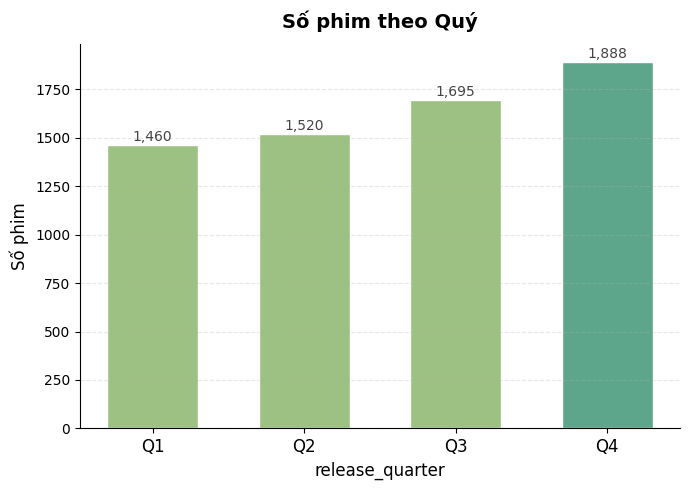

In [ ]:
# ── release_quarter ───────────────────────────────────────────────────────────
counts = df['release_quarter'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))
bar_colors = [DARK if v == counts.max() else SAGE for v in counts.values]
bars = ax.bar([1, 2, 3, 4], counts.values,
              color=bar_colors, edgecolor='white', width=0.6)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 5, f'{int(h):,}',
            ha='center', va='bottom', fontsize=10, color='#444')

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'], fontsize=12)
ax.set_title('Số phim theo Quý', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('release_quarter', fontsize=12)
ax.set_ylabel('Số phim', fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


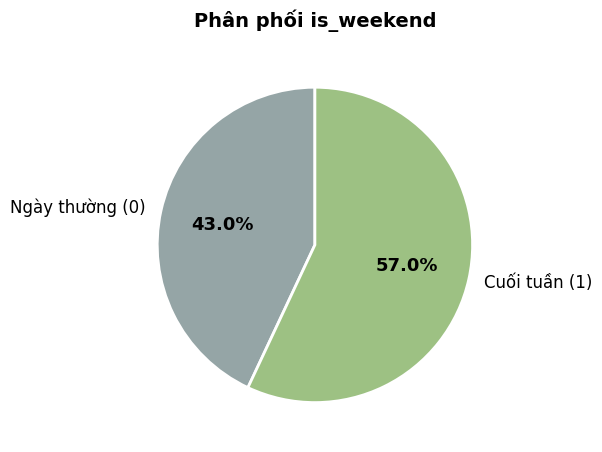

is_weekend
Ngày thường    2835
Cuối tuần      3756


In [ ]:
# ── is_weekend ────────────────────────────────────────────────────────────────
counts = df['is_weekend'].value_counts().sort_index()
labels = ['Ngày thường (0)', 'Cuối tuần (1)']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=labels,
    colors=[MUTED, SAGE],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('Phân phối is_weekend', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(counts.rename(index={0: 'Ngày thường', 1: 'Cuối tuần'}).to_string())


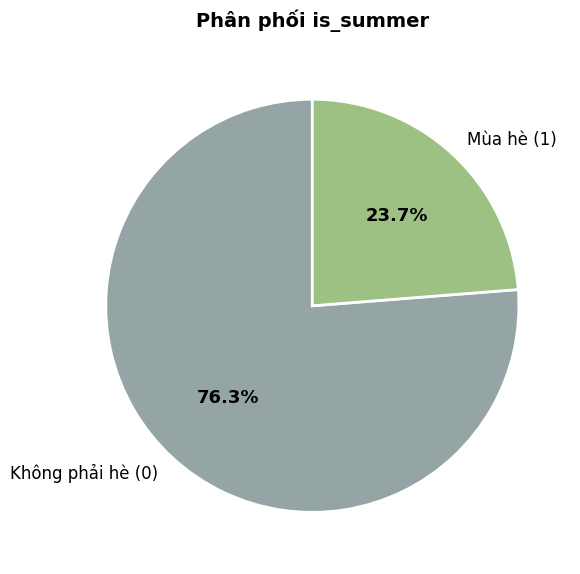

is_summer
Không phải hè    5026
Mùa hè           1565


In [ ]:
# ── is_summer ─────────────────────────────────────────────────────────────────
counts = df['is_summer'].value_counts().sort_index()
labels = ['Không phải hè (0)', 'Mùa hè (1)']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=labels,
    colors=[MUTED, SAGE],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('Phân phối is_summer', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(counts.rename(index={0: 'Không phải hè', 1: 'Mùa hè'}).to_string())


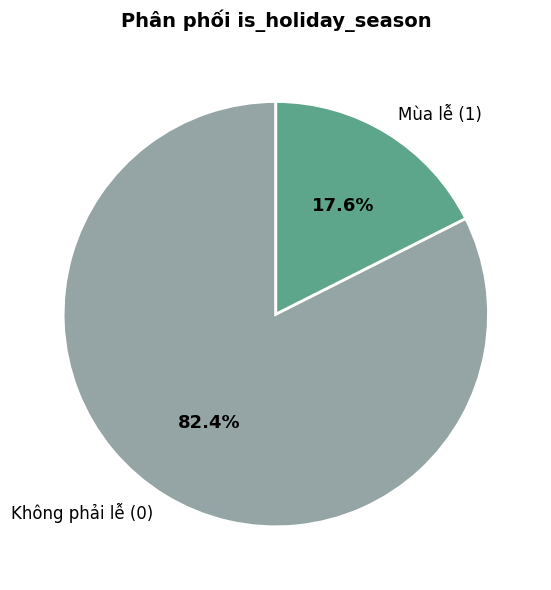

is_holiday_season
Không phải lễ    5433
Mùa lễ           1158


In [ ]:
# ── is_holiday_season ─────────────────────────────────────────────────────────
counts = df['is_holiday_season'].value_counts().sort_index()
labels = ['Không phải lễ (0)', 'Mùa lễ (1)']

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=labels,
    colors=[MUTED, DARK],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')

ax.set_title('Phân phối is_holiday_season', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print(counts.rename(index={0: 'Không phải lễ', 1: 'Mùa lễ'}).to_string())


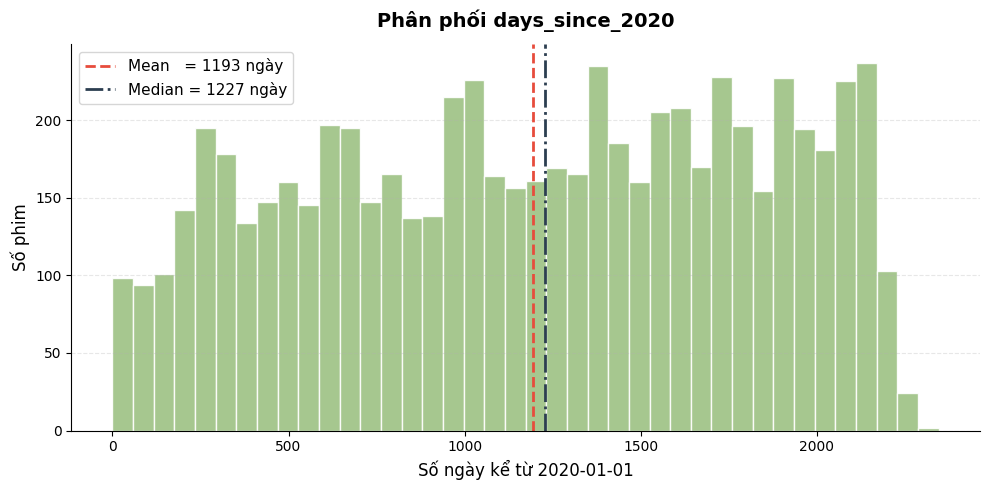

Skewness: -0.122
count    6563.0
mean     1193.2
std       623.1
min         0.0
25%       659.0
50%      1227.0
75%      1736.0
max      2346.0
Name: days_since_2020, dtype: float64


In [ ]:
# ── days_since_2020 ───────────────────────────────────────────────────────────
data = df['days_since_2020'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(data, bins=40, color=SAGE, edgecolor='white', alpha=0.9)

ax.axvline(data.mean(),   color=RED,      linewidth=2, linestyle='--',
           label=f'Mean   = {data.mean():.0f} ngày')
ax.axvline(data.median(), color='#2c3e50', linewidth=2, linestyle='-.',
           label=f'Median = {data.median():.0f} ngày')

ax.set_title('Phân phối days_since_2020', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Số ngày kể từ 2020-01-01', fontsize=12)
ax.set_ylabel('Số phim', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Skewness: {data.skew():.3f}")
print(data.describe().round(1))


## Kiểm tra tương quan với revenue

In [ ]:
from scipy.stats import spearmanr, mannwhitneyu

new_date_cols = ['release_year', 'release_month', 'release_quarter',
                 'is_weekend', 'is_summer', 'is_holiday_season', 'days_since_2020']

# Chỉ dùng hàng có revenue
df_corr = df.dropna(subset=['revenue'])

rows = []
for col in new_date_cols:
    series = df_corr[col].dropna()
    rev    = df_corr.loc[series.index, 'revenue']

    pearson_r          = round(series.corr(rev, method='pearson'), 4)
    spearman_r, sp_p   = spearmanr(series, rev)

    # Binary feature → Mann-Whitney U test
    # Continuous/ordinal → Spearman p-value
    if series.nunique() == 2:
        g0, g1 = rev[series == 0], rev[series == 1]
        _, p_val = mannwhitneyu(g0, g1, alternative='two-sided')
        test_name = 'Mann-Whitney U'
    else:
        p_val = sp_p
        test_name = 'Spearman'

    rows.append({
        'Feature'     : col,
        'Pearson r'   : pearson_r,
        'Spearman r'  : round(spearman_r, 4),
        'p-value'     : round(p_val, 4),
        'Test'        : test_name,
        'Significant' : 'YES' if p_val < 0.05 else 'NO'
    })

corr_df = pd.DataFrame(rows).sort_values('Spearman r', key=abs, ascending=False)
print(corr_df.to_string(index=False))


          Feature  Pearson r  Spearman r  p-value           Test Significant
       is_weekend     0.0872      0.0790   0.0000 Mann-Whitney U         YES
     release_year    -0.0507     -0.0369   0.0148       Spearman         YES
  days_since_2020    -0.0499     -0.0340   0.0246       Spearman         YES
        is_summer    -0.0095     -0.0174   0.2492 Mann-Whitney U          NO
is_holiday_season    -0.0066     -0.0033   0.8265 Mann-Whitney U          NO
  release_quarter     0.0019      0.0013   0.9311       Spearman          NO
    release_month    -0.0000      0.0001   0.9958       Spearman          NO


/tmp/ipykernel_1167/1359890799.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x=col, y='revenue',
/tmp/ipykernel_1167/1359890799.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x=col, y='revenue',
/tmp/ipykernel_1167/1359890799.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x=col, y='revenue',


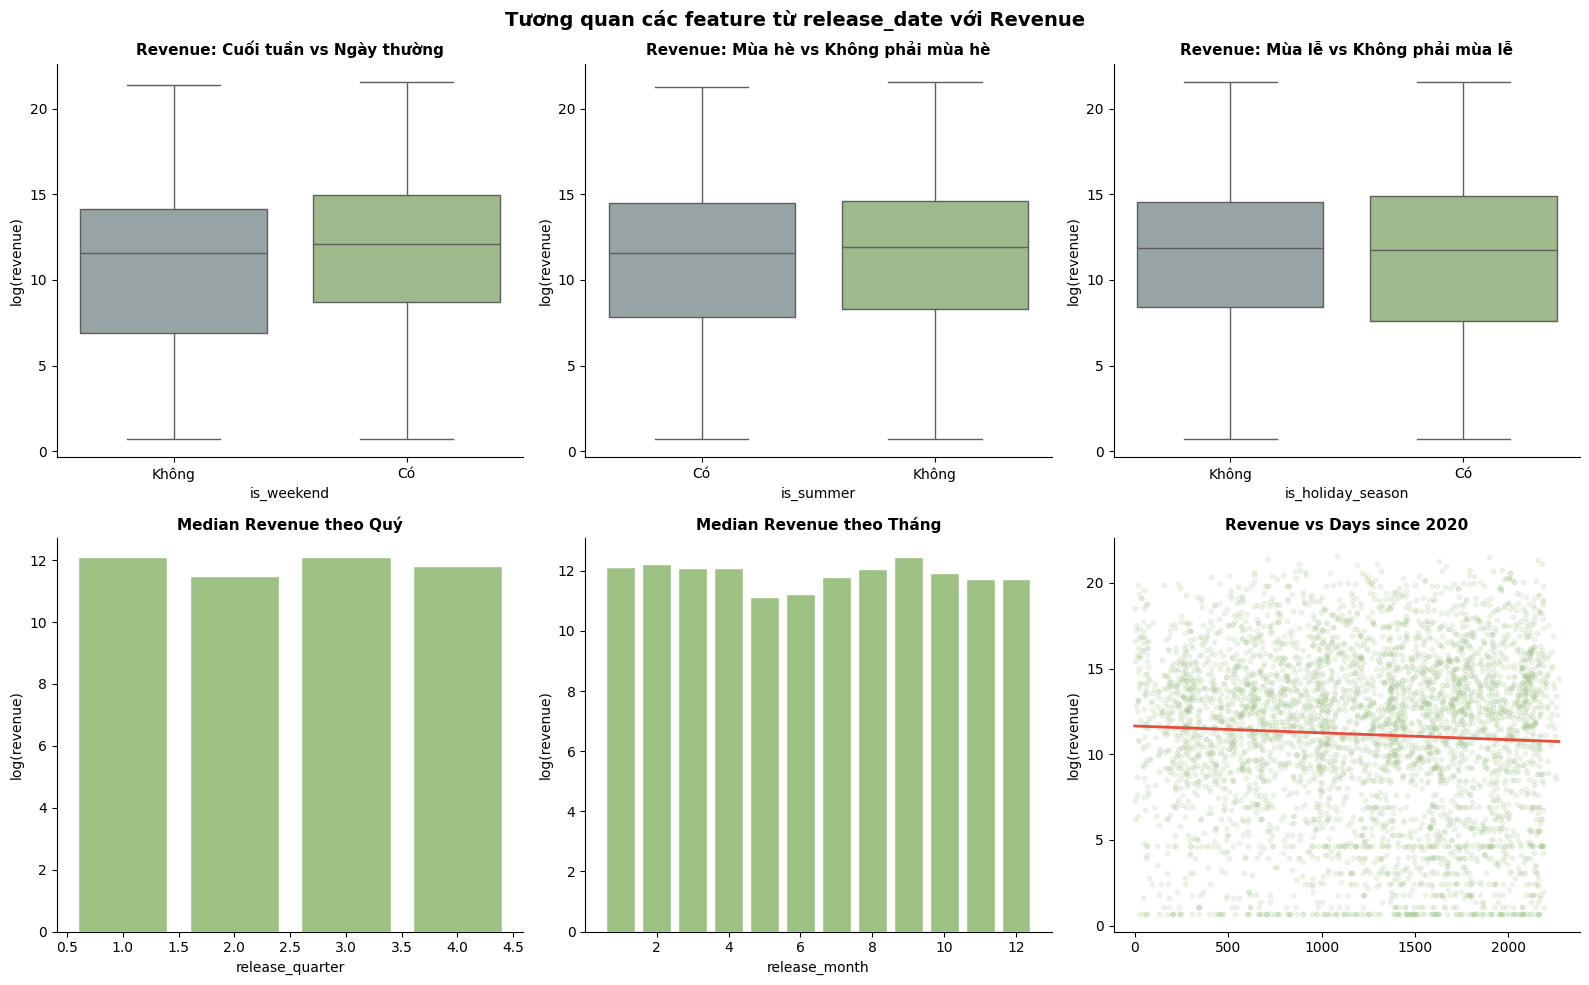

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

plot_configs = [
    # (col, kind, title)
    ('is_weekend',        'box', 'Revenue: Cuối tuần vs Ngày thường'),
    ('is_summer',         'box', 'Revenue: Mùa hè vs Không phải mùa hè'),
    ('is_holiday_season', 'box', 'Revenue: Mùa lễ vs Không phải mùa lễ'),
    ('release_quarter',   'bar', 'Median Revenue theo Quý'),
    ('release_month',     'bar', 'Median Revenue theo Tháng'),
    ('days_since_2020',   'scatter', 'Revenue vs Days since 2020'),
]

for ax, (col, kind, title) in zip(axes, plot_configs):

    if kind == 'box':
        labels = {0: 'Không', 1: 'Có'}
        data_plot = df_corr[[col, 'revenue']].copy()
        data_plot[col] = data_plot[col].map(labels)
        sns.boxplot(data=data_plot, x=col, y='revenue',
                    palette=['#95a5a6', '#9DC183'], ax=ax)

    elif kind == 'bar':
        med = df_corr.groupby(col)['revenue'].median()
        ax.bar(med.index.astype(int), med.values, color='#9DC183', edgecolor='white')
        ax.set_xlabel(col)

    elif kind == 'scatter':
        ax.scatter(df_corr[col], df_corr['revenue'],
                   alpha=0.15, s=10, color='#9DC183')
        m, b = np.polyfit(df_corr[col].dropna(),
                          df_corr.loc[df_corr[col].notna(), 'revenue'], 1)
        xline = np.linspace(df_corr[col].min(), df_corr[col].max(), 100)
        ax.plot(xline, m * xline + b, color='#e74c3c', linewidth=2)

    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('log(revenue)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Tương quan các feature từ release_date với Revenue',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Nhận xét:**

| Feature | Spearman r | p-value | Kết luận |
|---------|-----------|---------|----------|
| `is_weekend` | 0.079 | < 0.001 | **Giữ** — có ý nghĩa thống kê, phim cuối tuần doanh thu cao hơn |
| `release_year` | -0.037 | 0.015 | **Giữ thận trọng** — có ý nghĩa nhưng tương quan yếu |
| `days_since_2020` | -0.034 | 0.025 | **Bỏ** — trùng thông tin với `release_year`, chọn 1 trong 2 |
| `is_summer` | -0.017 | 0.249 | **Bỏ** — không có ý nghĩa thống kê (p > 0.05) |
| `is_holiday_season` | -0.003 | 0.827 | **Bỏ** — hoàn toàn không có ý nghĩa |
| `release_quarter` | 0.001 | 0.931 | **Bỏ** — không có ý nghĩa |
| `release_month` | 0.000 | 0.996 | **Bỏ** — không có ý nghĩa |

→ Từ 7 features tạo ra, **chỉ giữ lại `is_weekend` và `release_year`**.  
- Giả thuyết "mùa hè / mùa lễ ảnh hưởng doanh thu" không được xác nhận trên dataset này — có thể do dataset thiên về phim indie/streaming, không phải blockbuster.


Kiểm tra lại cột release_month bằng Kruskal-Wallis. Vì Spearman test kiểm tra quan hệ monotonic tuyến tính — tháng 1 < tháng 2 < ... < tháng 12. Nhưng thực tế revenue theo tháng không có dạng đó, nó có thể cao ở tháng 1, thấp tháng 5, cao lại tháng 9 — dạng non-monotonic nên Spearman miss.

In [ ]:
from scipy.stats import kruskal

groups = [df[df['release_month'] == m]['revenue'].dropna()
          for m in range(1, 13)]

stat, p = kruskal(*groups)
print(f"Kruskal-Wallis p-value: {p:.4f}")
# p < 0.05 → revenue khác nhau giữa các tháng → đáng giữ
# p > 0.05 → không có sự khác biệt → bỏ

Kruskal-Wallis p-value: 0.0609


**Tổng kết:**